In [2]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report


In [7]:
df= pd.read_csv(r"D:\SEM_VI\PATTERN_REC\pokemon.csv")

In [8]:
print(df.head())

                     abilities  against_bug  against_dark  against_dragon  \
0  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
1  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
2  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
3     ['Blaze', 'Solar Power']          0.5           1.0             1.0   
4     ['Blaze', 'Solar Power']          0.5           1.0             1.0   

   against_electric  against_fairy  against_fight  against_fire  \
0               0.5            0.5            0.5           2.0   
1               0.5            0.5            0.5           2.0   
2               0.5            0.5            0.5           2.0   
3               1.0            0.5            1.0           0.5   
4               1.0            0.5            1.0           0.5   

   against_flying  against_ghost  ...  percentage_male  pokedex_number  \
0             2.0            1.0  ...             88.1      

In [9]:
df.shape

(801, 41)

In [10]:
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [12]:
print(df.isnull().sum())

abilities              0
against_bug            0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0
attack                 0
base_egg_steps         0
base_happiness         0
base_total             0
capture_rate           0
classfication          0
defense                0
experience_growth      0
height_m              20
hp                     0
japanese_name          0
name                   0
percentage_male       98
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
type2                384
weight_kg             20
generation             0


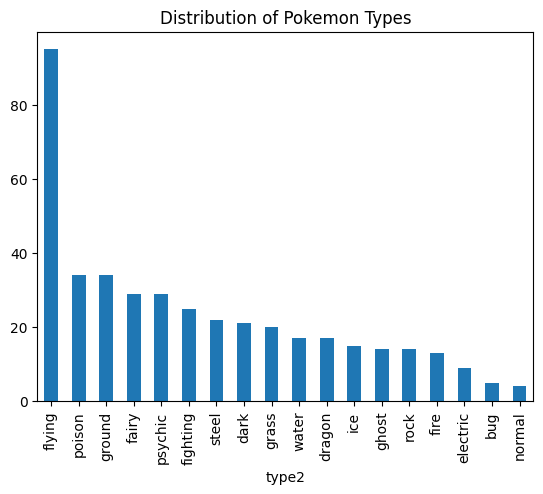

In [14]:
df['type2'].value_counts().plot(kind='bar')
plt.title('Distribution of Pokemon Types'); plt.show()

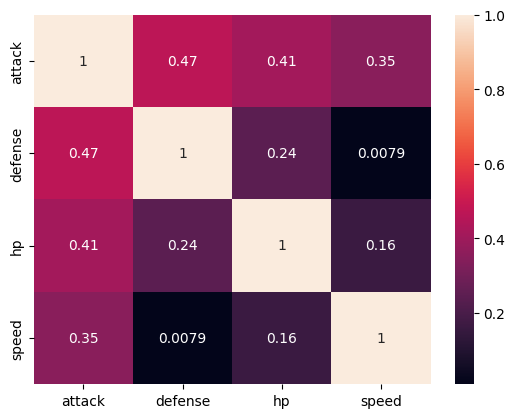

In [16]:
sns.heatmap(df[['attack','defense','hp','speed']].corr(),annot=True)
plt.show()

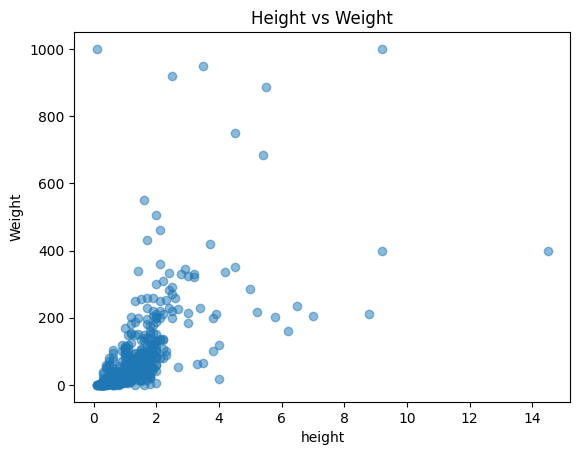

In [17]:
plt.scatter(df['height_m'],df['weight_kg'],alpha=0.5)
plt.xlabel('height'); plt.ylabel('Weight'); plt.title('Height vs Weight'); plt.show()

In [18]:
features = ['attack','defense','hp','speed','height_m','weight_kg']
df_clean =df[features + ['is_legendary'] ].dropna()
X = df_clean[features]
y = df_clean['is_legendary']

In [19]:
X_train ,X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42) 

In [20]:
clf = DecisionTreeClassifier(max_depth=5,random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("accuracy = ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy =  0.910828025477707
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       144
           1       0.45      0.38      0.42        13

    accuracy                           0.91       157
   macro avg       0.70      0.67      0.68       157
weighted avg       0.90      0.91      0.91       157

